**Cell 1 - Import Library & Baca Dataset**

Cell ini buat tahap persiapan yang ngimpor library Pandas, Matplotlib, dan Seaborn, terus baca dataset car_data.csv ke dalam variabel df.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('car_data.csv')
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


**Cell 2 - Statistik Deskriptif Atribut Numerik**

Cell ini nampilin rata-rata (mean), standar deviasi (std), nilai minimum (min), nilai maksimum (max), Q1 (25%), Q2/median (50%), dan Q3 (75%) dari atribut bertipe angka. Fungsi .describe()  otomatis cuma menghitung kolom numerik, jadi kolom object (Car_Name, Fuel_Type, dst) otomatis ga ikut ditampilin.

In [10]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


**Cell 3 - 10 Record Pertama dari Atribut Numerik**

Cell ini nampilin 10 record pertama, khusus untuk kolom kolom bertipe angka. select_dtypes(include='number') dipakai untuk memilih otomatis kolom Year, Selling_Price, Present_Price, Kms_Driven, Owner, terus .head(10) nampilin 10 baris pertamanya.

In [11]:
atribut_numerik = df.select_dtypes(include='number')
atribut_numerik.head(10)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
0,2014,3.35,5.59,27000,0
1,2013,4.75,9.54,43000,0
2,2017,7.25,9.85,6900,0
3,2011,2.85,4.15,5200,0
4,2014,4.60,6.87,42450,0
5,2018,9.25,9.83,2071,0
6,2015,6.75,8.12,18796,0
7,2015,6.50,8.61,33429,0
8,2016,8.75,8.89,20273,0
9,2015,7.45,8.92,42367,0


**Cell 4 - Jumlah Record, Jumlah Atribut, Nama Atribut, Jumlah Atribut Numerik**

Cell ini nampilin jumlah record (baris), jumlah atribut (kolom), nama-nama atribut, dan jumlah atribut bertipe angka. df.shape mengembalikan (jumlah baris, jumlah kolom), df.columns berisi nama-nama kolom, dan atribut_numerik (dari Cell 3) sudah berisi kolom kolom numerik aja sampai tinggal dihitung jumlah kolomnya.

In [12]:
print("Jumlah record  :", df.shape[0])
print("Jumlah atribut :", df.shape[1])
print("Nama atribut   :", list(df.columns))
print("Jumlah atribut numerik:", len(atribut_numerik.columns))

Jumlah record  : 301
Jumlah atribut : 9
Nama atribut   : ['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
Jumlah atribut numerik: 5


**Cell 5 - Jumlah Label dari Atribut Bertipe Object**

Cell ini nampilkan jumlah label/kategori unik dari setiap atribut bertipe object (Car_Name, Fuel_Type, Seller_Type, Transmission). select_dtypes(include='object') milih kolom kolom object, lalu .nunique() menghitung berapa nilai berbeda pada tiap kolom tersebut.

In [13]:
atribut_kategorikal = df.select_dtypes(include='object')

for kolom in atribut_kategorikal.columns:
    print(kolom, ":", df[kolom].nunique(), "label")

Car_Name : 98 label
Fuel_Type : 3 label
Seller_Type : 2 label
Transmission : 2 label


**Cell 6 - Visualisasi Dataset (2 Jenis Grafik)**

Cell ini nampilin dua jenis grafik. Grafik pertama (Histogram) memvisualisasikan atribut numerik Selling_Price untuk liat distribusi/sebaran harga jual mobil. Grafik kedua (Batang) memvisualisasikan atribut kategorikal Fuel_Type untuk membandingkan jumlah mobil berdasarkan jenis bahan bakarnya, dihitung dulu jumlah masing-masing kategori dengan value_counts(), baru ditampilkan dengan plt.bar().

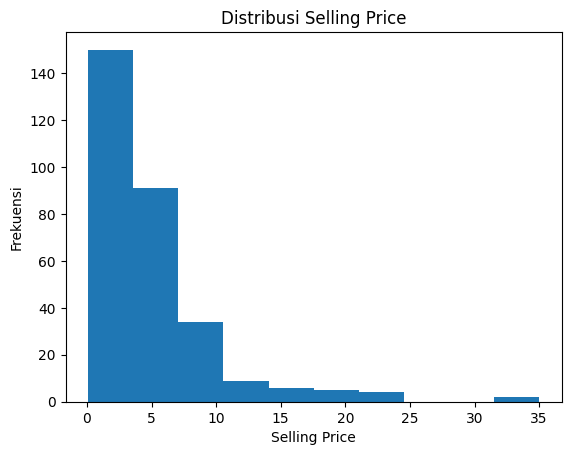

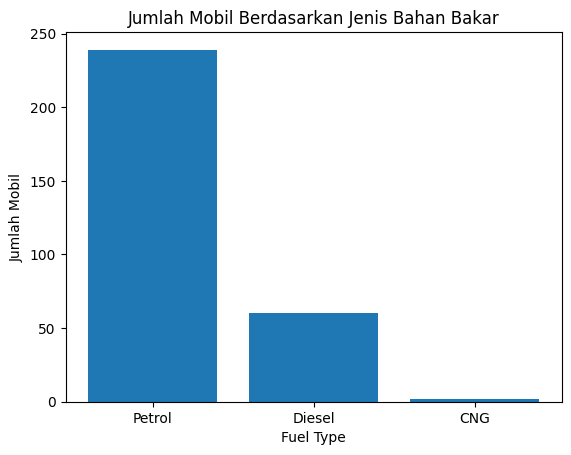

In [15]:
plt.hist(df['Selling_Price'])
plt.title('Distribusi Selling Price')
plt.xlabel('Selling Price')
plt.ylabel('Frekuensi')
plt.show()

jumlah_fuel = df['Fuel_Type'].value_counts()

plt.bar(jumlah_fuel.index, jumlah_fuel.values)
plt.title('Jumlah Mobil Berdasarkan Jenis Bahan Bakar')
plt.xlabel('Fuel Type')
plt.ylabel('Jumlah Mobil')
plt.show()

**Cell 7 - Heatmap Korelasi Atribut Numerik**

Cell ini nampilin korelasi antar atribut numerik menggunakan heatmap. .corr() menghitung nilai korelasi antar kolom numerik, lalu sns.heatmap() memvisualisasikannya dalam bentuk warna annot=True supaya nilai korelasinya juga muncul di tiap kotak.

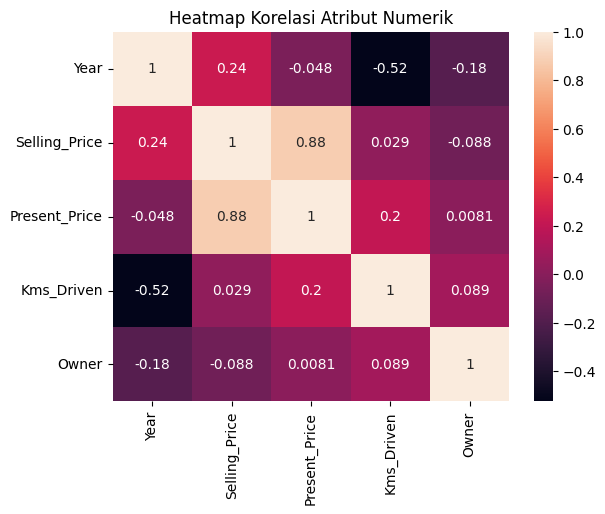

In [16]:
korelasi = df[atribut_numerik.columns].corr()

sns.heatmap(korelasi, annot=True)
plt.title('Heatmap Korelasi Atribut Numerik')
plt.show()